In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

In [3]:
# Loading the data
data = pd.read_csv("data/Country-data.csv")
data.head()
dataset = data.iloc[:, 1:]
dataset.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Clustering

Text(0.5, 0, 'number of components')

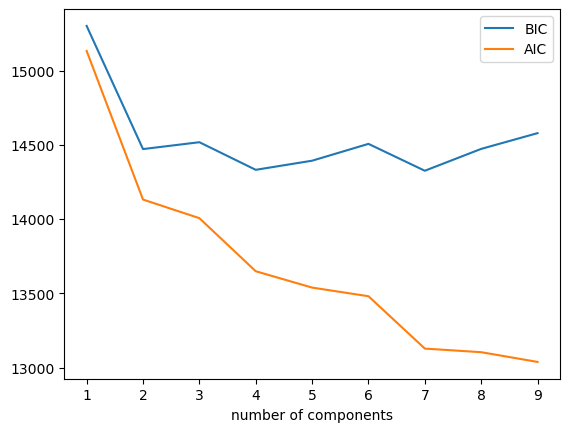

In [4]:
# Finding optimal number of cluster
n_components = np.arange(1,10)
models = [GaussianMixture(n, 
                          random_state = 1502).fit(dataset)
          for n in n_components]
plt.plot(n_components,
         [m.bic(dataset) for m in models],
         label = 'BIC')
plt.plot(n_components,
         [m.aic(dataset) for m in models],
         label = 'AIC')
plt.legend()
plt.xlabel('number of components')

In [5]:
# GMM
model = GaussianMixture(n_components = 4, 
                        random_state = 1502).fit(dataset)

In [7]:
# Predicting cluster by country
cluster = pd.Series(model.predict(dataset))
cluster[:3]

0    0
1    2
2    2
dtype: int64

In [8]:
# Assign a cluster in the dataframe
data['Cluster'] = cluster
data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [9]:
# Searching a specific country
data.loc[data['country'] == 'Portugal']

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
122,Portugal,3.9,29.9,11.0,37.4,27200,0.643,79.8,1.39,22500,3


In [10]:
# Create the probabilities of belonging to any cluster
probabilities = round(pd.DataFrame(model.predict_proba(dataset)),2)
probabilities.head(2)

,0,1,2,3
0,1.00,0.0,0.00,0.0
1,0.13,0.0,0.87,0.0


In [11]:
# Joining probabilities with data
data = pd.concat([data, probabilities], axis = 1)
data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,0,1,2,3
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0,1.00,0.0,0.00,0.0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,0.13,0.0,0.87,0.0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,0.01,0.0,0.99,0.0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0,1.00,0.0,0.00,0.0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,0.00,0.0,1.00,0.0


In [12]:
# Interpreting the cluster
interpretation = pd.DataFrame(model.means_,
                              columns = list(dataset.columns))
interpretation

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,66.846300,31.896830,6.232848,46.039461,4341.258795,10.197586,63.698617,4.015042,1956.588160
1,6.228571,96.442857,5.712857,68.571429,80342.857143,6.388714,80.285714,1.767143,65442.857143
2,17.081825,45.524950,6.546408,48.290282,16409.070974,6.939257,74.553385,2.073424,9449.315379
3,5.228185,45.069273,9.238110,41.275377,38909.739415,2.887746,80.007217,1.866028,37526.367387


In [17]:
data[data[3] == 1]

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,0,1,2,3
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,3,0.0,0.0,0.0,1.0
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,3,0.0,0.0,0.0,1.0
11,Bahrain,8.6,69.5,4.97,50.9,41100,7.440,76.0,2.16,20700,3,0.0,0.0,0.0,1.0
15,Belgium,4.5,76.4,10.70,74.7,41100,1.880,80.0,1.86,44400,3,0.0,0.0,0.0,1.0
29,Canada,5.6,29.1,11.30,31.0,40700,2.870,81.3,1.63,47400,3,0.0,0.0,0.0,1.0
42,Cyprus,3.6,50.2,5.97,57.5,33900,2.010,79.9,1.42,30800,3,0.0,0.0,0.0,1.0
44,Denmark,4.1,50.5,11.40,43.6,44000,3.220,79.5,1.87,58000,3,0.0,0.0,0.0,1.0
53,Finland,3.0,38.7,8.95,37.4,39800,0.351,80.0,1.87,46200,3,0.0,0.0,0.0,1.0
54,France,4.2,26.8,11.90,28.1,36900,1.050,81.4,2.03,40600,3,0.0,0.0,0.0,1.0
58,Germany,4.2,42.3,11.60,37.1,40400,0.758,80.1,1.39,41800,3,0.0,0.0,0.0,1.0
